In [1]:
def extract_features_lstm(parent_dir='dataset/Audio_Speech_Actors_01-24'):

    features = []
    labels = []

    max_pad_len = 174

    for actor_folder in os.listdir(parent_dir):

        actor_path = os.path.join(parent_dir, actor_folder)

        if not os.path.isdir(actor_path):
            continue

        for file in os.listdir(actor_path):

            if file.endswith('.wav'):

                file_path = os.path.join(actor_path, file)

                emotion_code = file.split('-')[2]

                emotion = emotion_dict.get(emotion_code)

                if emotion is None:
                    continue

                try:
                    audio, sample_rate = librosa.load(
                        file_path,
                        res_type='kaiser_fast'
                    )

                    mfccs = librosa.feature.mfcc(
                        y=audio,
                        sr=sample_rate,
                        n_mfcc=40
                    )

                    # Padding
                    pad_width = max_pad_len - mfccs.shape[1]

                    if pad_width > 0:
                        mfccs = np.pad(
                            mfccs,
                            pad_width=((0, 0), (0, pad_width)),
                            mode='constant'
                        )
                    else:
                        mfccs = mfccs[:, :max_pad_len]

                    features.append(mfccs.T)
                    labels.append(emotion)

                except Exception as e:
                    print("Error:", file_path)
                    print(e)

    return np.array(features), np.array(labels)

In [2]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

print(tf.__version__)

2.21.0


In [4]:
# Emotion mapping (you can change as per your needs)
emotion_dict = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

In [5]:
X, y = extract_features_lstm()

print(X.shape)

(952, 174, 40)


In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [9]:
model = Sequential()

model.add(
    LSTM(
        128,
        input_shape=(174, 40),
        return_sequences=False
    )
)

model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(len(label_encoder.classes_), activation='softmax'))

C:\Users\SANJANA BARUI\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 165ms/step - accuracy: 0.1537 - loss: 2.0579 - val_accuracy: 0.2147 - val_loss: 1.9898
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - accuracy: 0.2168 - loss: 1.9742 - val_accuracy: 0.3037 - val_loss: 1.9181
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.2418 - loss: 1.8944 - val_accuracy: 0.2880 - val_loss: 1.8445
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step - accuracy: 0.2943 - loss: 1.7658 - val_accuracy: 0.3089 - val_loss: 1.7148
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.3417 - loss: 1.6675 - val_accuracy: 0.3665 - val_loss: 1.6617
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.3614 - loss: 1.6107 - val_accuracy: 0.3351 - val_loss: 1.6391
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.3942 - loss: 1.5509 - val_accuracy: 0.3665 - val_loss: 1.5666
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - accuracy: 0.4008 - loss: 1.5075 - val_accuracy: 0.

In [15]:
y_pred = model.predict(X_test)

y_pred_classes = y_pred.argmax(axis=1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step


In [16]:
from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(y_test, y_pred_classes))

Test Accuracy: 0.5340314136125655


In [17]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       angry       0.82      0.62      0.71        29
        calm       0.52      0.62      0.57        21
     disgust       0.64      0.56      0.60        32
     fearful       0.44      0.38      0.41        21
       happy       0.61      0.54      0.57        26
     neutral       0.50      0.29      0.36        14
         sad       0.29      0.48      0.36        23
   surprised       0.55      0.64      0.59        25

    accuracy                           0.53       191
   macro avg       0.55      0.52      0.52       191
weighted avg       0.56      0.53      0.54       191



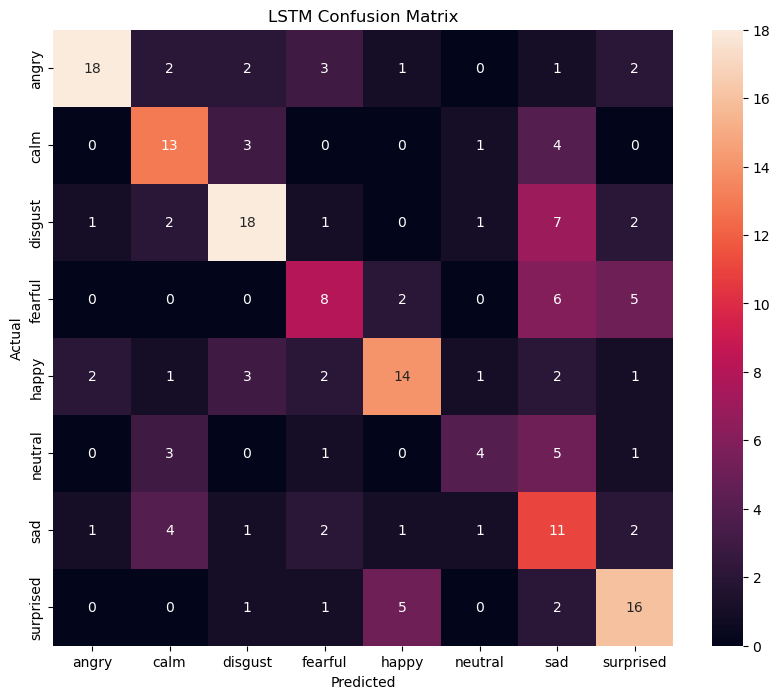

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")

plt.show()

In [21]:
model.save("speech_emotion_lstm_model.h5")